# GLFTMM Result Curves

Use `sim/report.py` to discover result folders and plot the curve for every folder.

In [1]:
from __future__ import annotations

import importlib
import json
import sys
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import display

REPO_ROOT = Path("/home/kang/glftmm_var")
if str(REPO_ROOT) not in sys.path:
    sys.path.insert(0, str(REPO_ROOT))

report_tools = importlib.import_module("sim.report")

try:
    get_ipython().run_line_magic("matplotlib", "inline")
except NameError:
    pass

plt.rcParams["figure.dpi"] = 120
pd.set_option("display.max_colwidth", 180)
pd.set_option("display.max_rows", 200)

Edit the variables below when you want a different symbol, date range, folder keyword, or plotting density.

In [2]:
with open(REPO_ROOT / "config/config.json", "r", encoding="utf-8") as fh:
    CONFIG = json.load(fh)

ROOT_DIR = Path(CONFIG["paths"]["output_dir"])
SYMBOL = CONFIG.get("symbols", ["BTCUSDT"])[0]

# Use None for the full available range. Date format can be YYYY-MM-DD or YYYYMMDD.
SRT = None
END = None
EXCLUDE_DATE = None

# Optional folder-path substring filter, for example "md1" or "pg10x50".
KEYWORD = None

# Larger EVERY is faster and lighter. Set lower for smoother intraday curves.
EVERY = 500

# PNL_ONLY=True plots only total PnL curves. False plots price/inventory/PnL/volume panels.
PNL_ONLY = False
NORMALIZE = False

# Plot folders in batches so each chart remains readable.
BATCH_SIZE = 6
NUM_WORKERS = 4

# Set to an integer while testing, for example 5. Use None for every discovered folder.
MAX_FOLDERS = None

ROOT_DIR, SYMBOL

(PosixPath('/data/users/kang/backtest/glftmm_var/result'), 'BTCUSDT')

Discover every leaf folder that contains matching parquet reports.

In [3]:
folders, counts = report_tools.get_folders_with_counts(
    ROOT_DIR,
    SYMBOL,
    srt=SRT,
    end=END,
    exclude_date=EXCLUDE_DATE,
    keyword=KEYWORD,
)

folder_df = pd.DataFrame(
    {
        "run_id": np.arange(len(folders), dtype=int),
        "file_count": counts,
        "folder": folders,
    }
)

def run_name(folder: str | Path) -> str:
    path = Path(folder)
    if path.name == "strat__all" and path.parent.name:
        return path.parent.name
    return path.name

if not folder_df.empty:
    folder_df.insert(1, "run_name", folder_df["folder"].map(run_name))

print(f"found {len(folder_df)} folders under {ROOT_DIR}")
display(folder_df)

if folder_df.empty:
    raise FileNotFoundError(
        f"no report parquet folders found under {ROOT_DIR} for symbol={SYMBOL}, keyword={KEYWORD}"
    )

found 24 folders under /data/users/kang/backtest/glftmm_var/result


,run_id,run_name,file_count,folder
0,0,sim__asi1__asv0__fr1000__isk0x1__lat2__lbi300__vlb300__mfm3em05__mhtm1__mp500000__mon100__moq0__md0__ink__vnsigma__ocu0x1x0__oa1000__pcp100000__pp1__pg5x105x10xexponentialx0p3_...,51,/data/users/kang/backtest/glftmm_var/result/BTCUSDT/sim__asi1__asv0__fr1000__isk0x1__lat2__lbi300__vlb300__mfm3em05__mhtm1__mp500000__mon100__moq0__md0__ink__vnsigma__ocu0x1x0_...
1,1,sim__asi1__asv0__fr1000__isk0x1__lat2__lbi300__vlb300__mfm3em05__mhtm1__mp500000__mon100__moq0__md0__ink__vnsigma__ocu0x1x0__oa1000__pcp100000__pp1__pg5x55x10xpowerx2__qp3__sl0...,52,/data/users/kang/backtest/glftmm_var/result/BTCUSDT/sim__asi1__asv0__fr1000__isk0x1__lat2__lbi300__vlb300__mfm3em05__mhtm1__mp500000__mon100__moq0__md0__ink__vnsigma__ocu0x1x0_...
2,2,sim__asi1__asv0__fr1000__isk0x1__lat2__lbi300__vlb300__mfm3em05__mhtm1__mp500000__mon100__moq0__md0__ink__vnsigma__ocu0x1x0__oa1000__pcp100000__pp1__pg5x55x10xpowerx3__qp3__sl0...,53,/data/users/kang/backtest/glftmm_var/result/BTCUSDT/sim__asi1__asv0__fr1000__isk0x1__lat2__lbi300__vlb300__mfm3em05__mhtm1__mp500000__mon100__moq0__md0__ink__vnsigma__ocu0x1x0_...
3,3,sim__asi1__asv0__fr1000__isk0x1__lat2__lbi300__vlb300__mfm3em05__mhtm1__mp500000__mon100__moq0__md0__ink__vnsigma__ocu0x1x0__oa1000__pcp250000__pp1__pg5x105x10xexponentialx0p3_...,51,/data/users/kang/backtest/glftmm_var/result/BTCUSDT/sim__asi1__asv0__fr1000__isk0x1__lat2__lbi300__vlb300__mfm3em05__mhtm1__mp500000__mon100__moq0__md0__ink__vnsigma__ocu0x1x0_...
4,4,sim__asi1__asv0__fr1000__isk0x1__lat2__lbi300__vlb300__mfm3em05__mhtm1__mp500000__mon100__moq0__md0__ink__vnsigma__ocu0x1x0__oa1000__pcp250000__pp1__pg5x55x10xpowerx2__qp3__sl0...,49,/data/users/kang/backtest/glftmm_var/result/BTCUSDT/sim__asi1__asv0__fr1000__isk0x1__lat2__lbi300__vlb300__mfm3em05__mhtm1__mp500000__mon100__moq0__md0__ink__vnsigma__ocu0x1x0_...
5,5,sim__asi1__asv0__fr1000__isk0x1__lat2__lbi300__vlb300__mfm3em05__mhtm1__mp500000__mon100__moq0__md0__ink__vnsigma__ocu0x1x0__oa1000__pcp250000__pp1__pg5x55x10xpowerx3__qp3__sl0...,50,/data/users/kang/backtest/glftmm_var/result/BTCUSDT/sim__asi1__asv0__fr1000__isk0x1__lat2__lbi300__vlb300__mfm3em05__mhtm1__mp500000__mon100__moq0__md0__ink__vnsigma__ocu0x1x0_...
6,6,sim__asi1__asv0__fr1000__isk0x1__lat2__lbi300__vlb300__mfm3em05__mhtm1__mp500000__mon100__moq0__md1__ink__vnsigma__ocu0x1x0__oa1000__pcp100000__pp1__pg5x105x10xexponentialx0p3_...,51,/data/users/kang/backtest/glftmm_var/result/BTCUSDT/sim__asi1__asv0__fr1000__isk0x1__lat2__lbi300__vlb300__mfm3em05__mhtm1__mp500000__mon100__moq0__md1__ink__vnsigma__ocu0x1x0_...
7,7,sim__asi1__asv0__fr1000__isk0x1__lat2__lbi300__vlb300__mfm3em05__mhtm1__mp500000__mon100__moq0__md1__ink__vnsigma__ocu0x1x0__oa1000__pcp100000__pp1__pg5x55x10xpowerx2__qp3__sl0...,50,/data/users/kang/backtest/glftmm_var/result/BTCUSDT/sim__asi1__asv0__fr1000__isk0x1__lat2__lbi300__vlb300__mfm3em05__mhtm1__mp500000__mon100__moq0__md1__ink__vnsigma__ocu0x1x0_...
8,8,sim__asi1__asv0__fr1000__isk0x1__lat2__lbi300__vlb300__mfm3em05__mhtm1__mp500000__mon100__moq0__md1__ink__vnsigma__ocu0x1x0__oa1000__pcp100000__pp1__pg5x55x10xpowerx3__qp3__sl0...,51,/data/users/kang/backtest/glftmm_var/result/BTCUSDT/sim__asi1__asv0__fr1000__isk0x1__lat2__lbi300__vlb300__mfm3em05__mhtm1__mp500000__mon100__moq0__md1__ink__vnsigma__ocu0x1x0_...
9,9,sim__asi1__asv0__fr1000__isk0x1__lat2__lbi300__vlb300__mfm3em05__mhtm1__mp500000__mon100__moq0__md1__ink__vnsigma__ocu0x1x0__oa1000__pcp250000__pp1__pg5x105x10xexponentialx0p3_...,49,/data/users/kang/backtest/glftmm_var/result/BTCUSDT/sim__asi1__asv0__fr1000__isk0x1__lat2__lbi300__vlb300__mfm3em05__mhtm1__mp500000__mon100__moq0__md1__ink__vnsigma__ocu0x1x0_...


Helper functions for selecting folders and calling `report_tools.report(...)`.

In [4]:
def choose_folders(
    indices: list[int] | tuple[int, ...] | None = None,
    contains: str | None = None,
    limit: int | None = MAX_FOLDERS,
) -> pd.DataFrame:
    df = folder_df.copy()
    if contains is not None:
        df = df[df["folder"].str.contains(contains, regex=False)]
    if indices is not None:
        wanted = list(indices)
        df = df[df["run_id"].isin(wanted)]
        df = df.set_index("run_id").reindex(wanted).dropna(subset=["folder"]).reset_index()
    if limit is not None:
        df = df.head(int(limit))
    return df.reset_index(drop=True)


def plot_folder_batch(
    df: pd.DataFrame,
    *,
    pnl_only: bool = PNL_ONLY,
    every: int = EVERY,
    normalize: bool = NORMALIZE,
) -> pd.DataFrame:
    if df.empty:
        raise ValueError("empty folder selection")

    folders_to_plot = df["folder"].tolist()
    labels = [f"{int(run_id):03d}" for run_id in df["run_id"]]

    stats = report_tools.report(
        folders_to_plot,
        every=every,
        pnl_only=pnl_only,
        srt=SRT,
        end=END,
        exclude_date=EXCLUDE_DATE,
        labels=labels,
        normalize=normalize,
        num_workers=NUM_WORKERS,
    )

    metrics = pd.DataFrame(stats)
    metrics.insert(0, "run_id", labels[: len(metrics)])
    metrics.insert(1, "file_count", df["file_count"].to_list()[: len(metrics)])
    metrics.insert(2, "folder", folders_to_plot[: len(metrics)])
    display(metrics)
    return metrics

Plot every discovered folder, split into batches.

batch 1: run_id 000..005


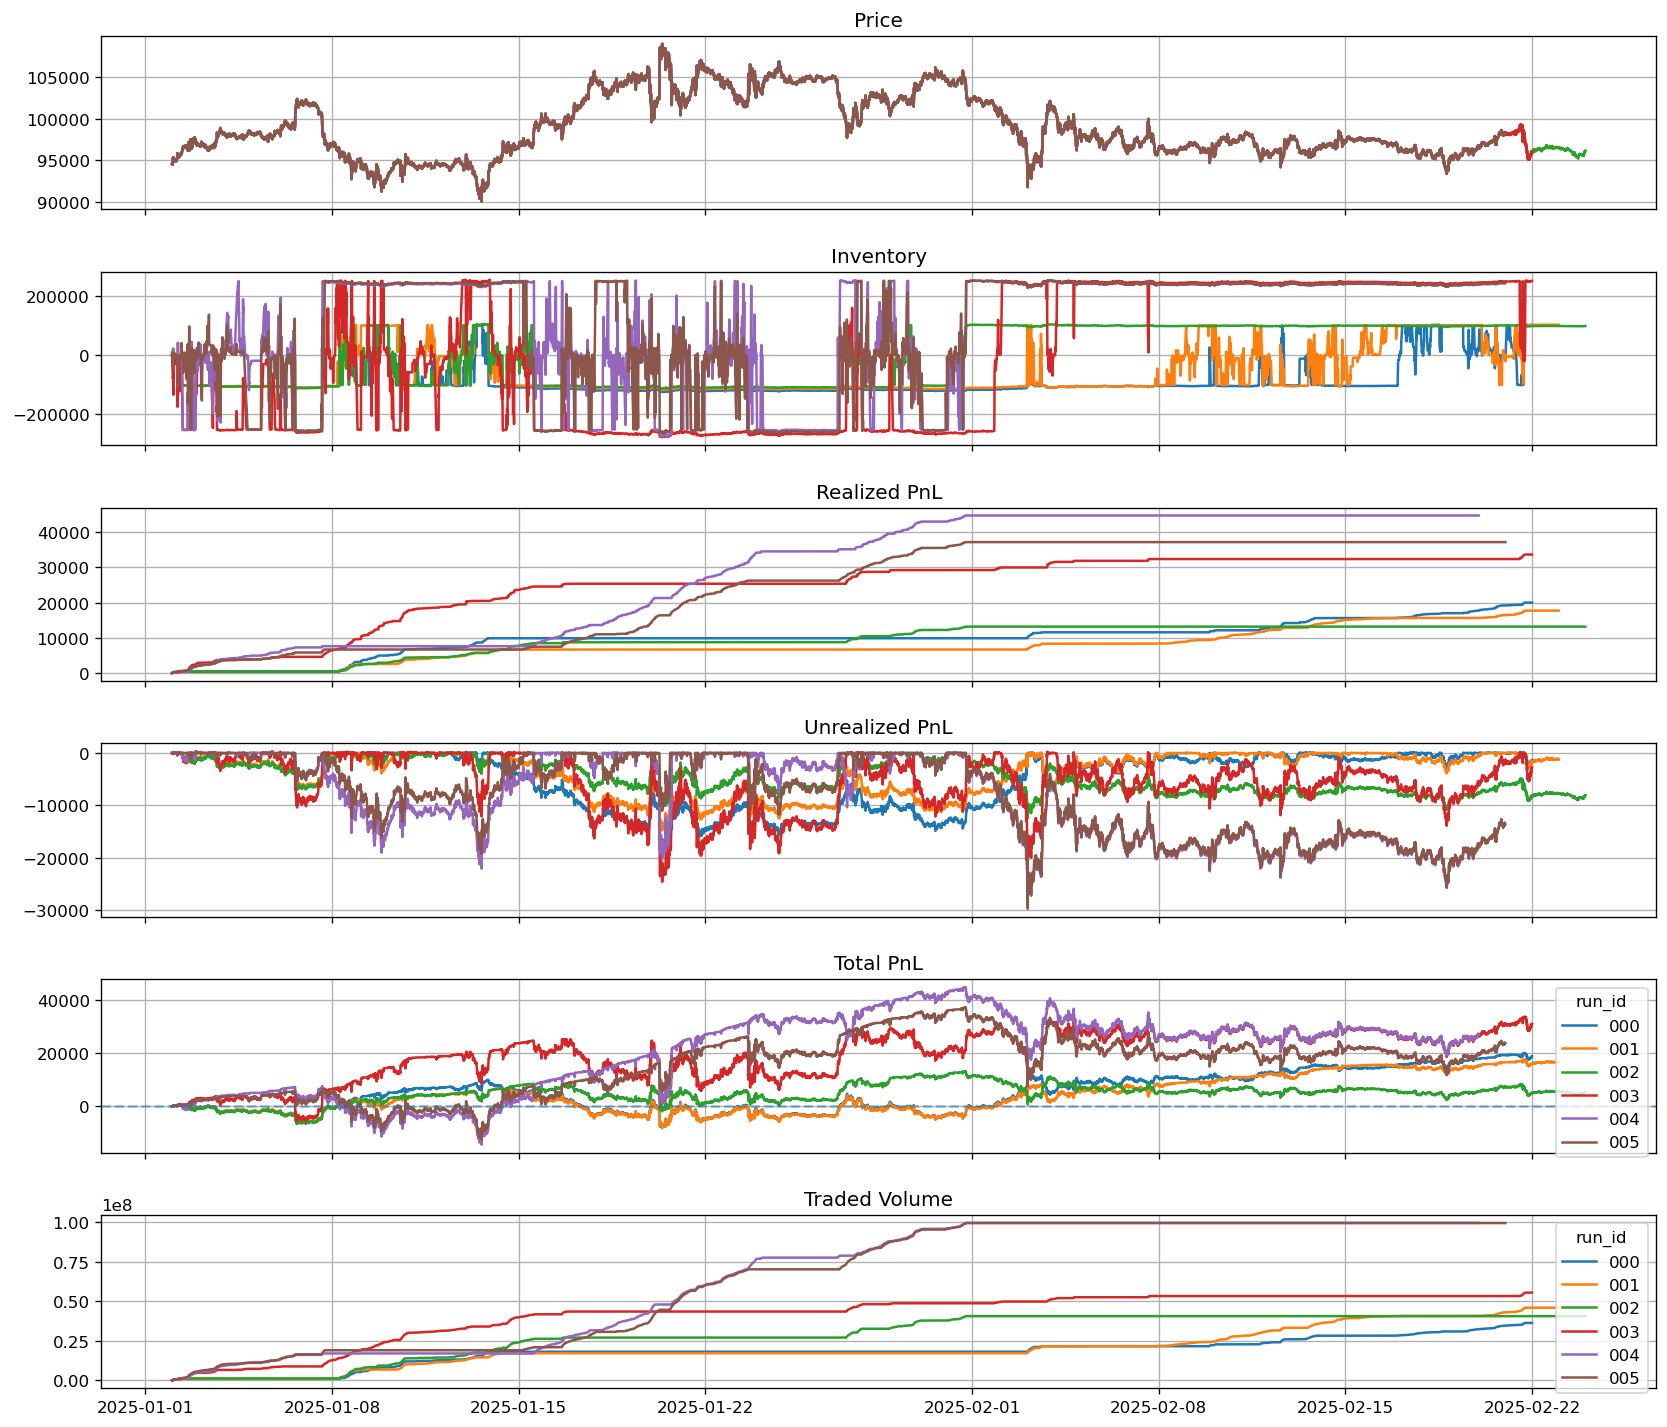

,run_id,file_count,folder,pnls,sharpes,calmars,max_drawdown,annual_return,calmar,sharpe,daily_turnover,spnl
0,000,51,/data/users/kang/backtest/glftmm_var/result/BTCUSDT/sim__asi1__asv0__fr1000__isk0x1__lat2__lbi300__vlb300__mfm3em05__mhtm1__mp500000__mon100__moq0__md0__ink__vnsigma__ocu0x1x0_...,18668.346321,0.179090,10.694173,13126.996454,140382.370939,10.694173,0.179090,7.079169e+05,0.000513
1,001,52,/data/users/kang/backtest/glftmm_var/result/BTCUSDT/sim__asi1__asv0__fr1000__isk0x1__lat2__lbi300__vlb300__mfm3em05__mhtm1__mp500000__mon100__moq0__md0__ink__vnsigma__ocu0x1x0_...,16209.799377,0.152100,10.648897,11106.089987,118267.606490,10.648897,0.152100,8.643722e+05,0.000352
2,002,53,/data/users/kang/backtest/glftmm_var/result/BTCUSDT/sim__asi1__asv0__fr1000__isk0x1__lat2__lbi300__vlb300__mfm3em05__mhtm1__mp500000__mon100__moq0__md0__ink__vnsigma__ocu0x1x0_...,5164.198978,0.056091,5.565252,7569.708078,42127.332614,5.565252,0.056091,7.590929e+05,0.000127
3,003,51,/data/users/kang/backtest/glftmm_var/result/BTCUSDT/sim__asi1__asv0__fr1000__isk0x1__lat2__lbi300__vlb300__mfm3em05__mhtm1__mp500000__mon100__moq0__md0__ink__vnsigma__ocu0x1x0_...,30948.894845,0.116265,13.046239,15641.882637,204067.732333,13.046239,0.116265,1.015479e+06,0.000557
4,004,49,/data/users/kang/backtest/glftmm_var/result/BTCUSDT/sim__asi1__asv0__fr1000__isk0x1__lat2__lbi300__vlb300__mfm3em05__mhtm1__mp500000__mon100__moq0__md0__ink__vnsigma__ocu0x1x0_...,30909.107507,0.162238,11.612838,18405.295401,213737.721546,11.612838,0.162238,1.932128e+06,0.000310
5,005,50,/data/users/kang/backtest/glftmm_var/result/BTCUSDT/sim__asi1__asv0__fr1000__isk0x1__lat2__lbi300__vlb300__mfm3em05__mhtm1__mp500000__mon100__moq0__md0__ink__vnsigma__ocu0x1x0_...,23598.885380,0.116149,8.841367,18149.513445,160466.503132,8.841367,0.116149,1.912918e+06,0.000237


batch 2: run_id 006..011


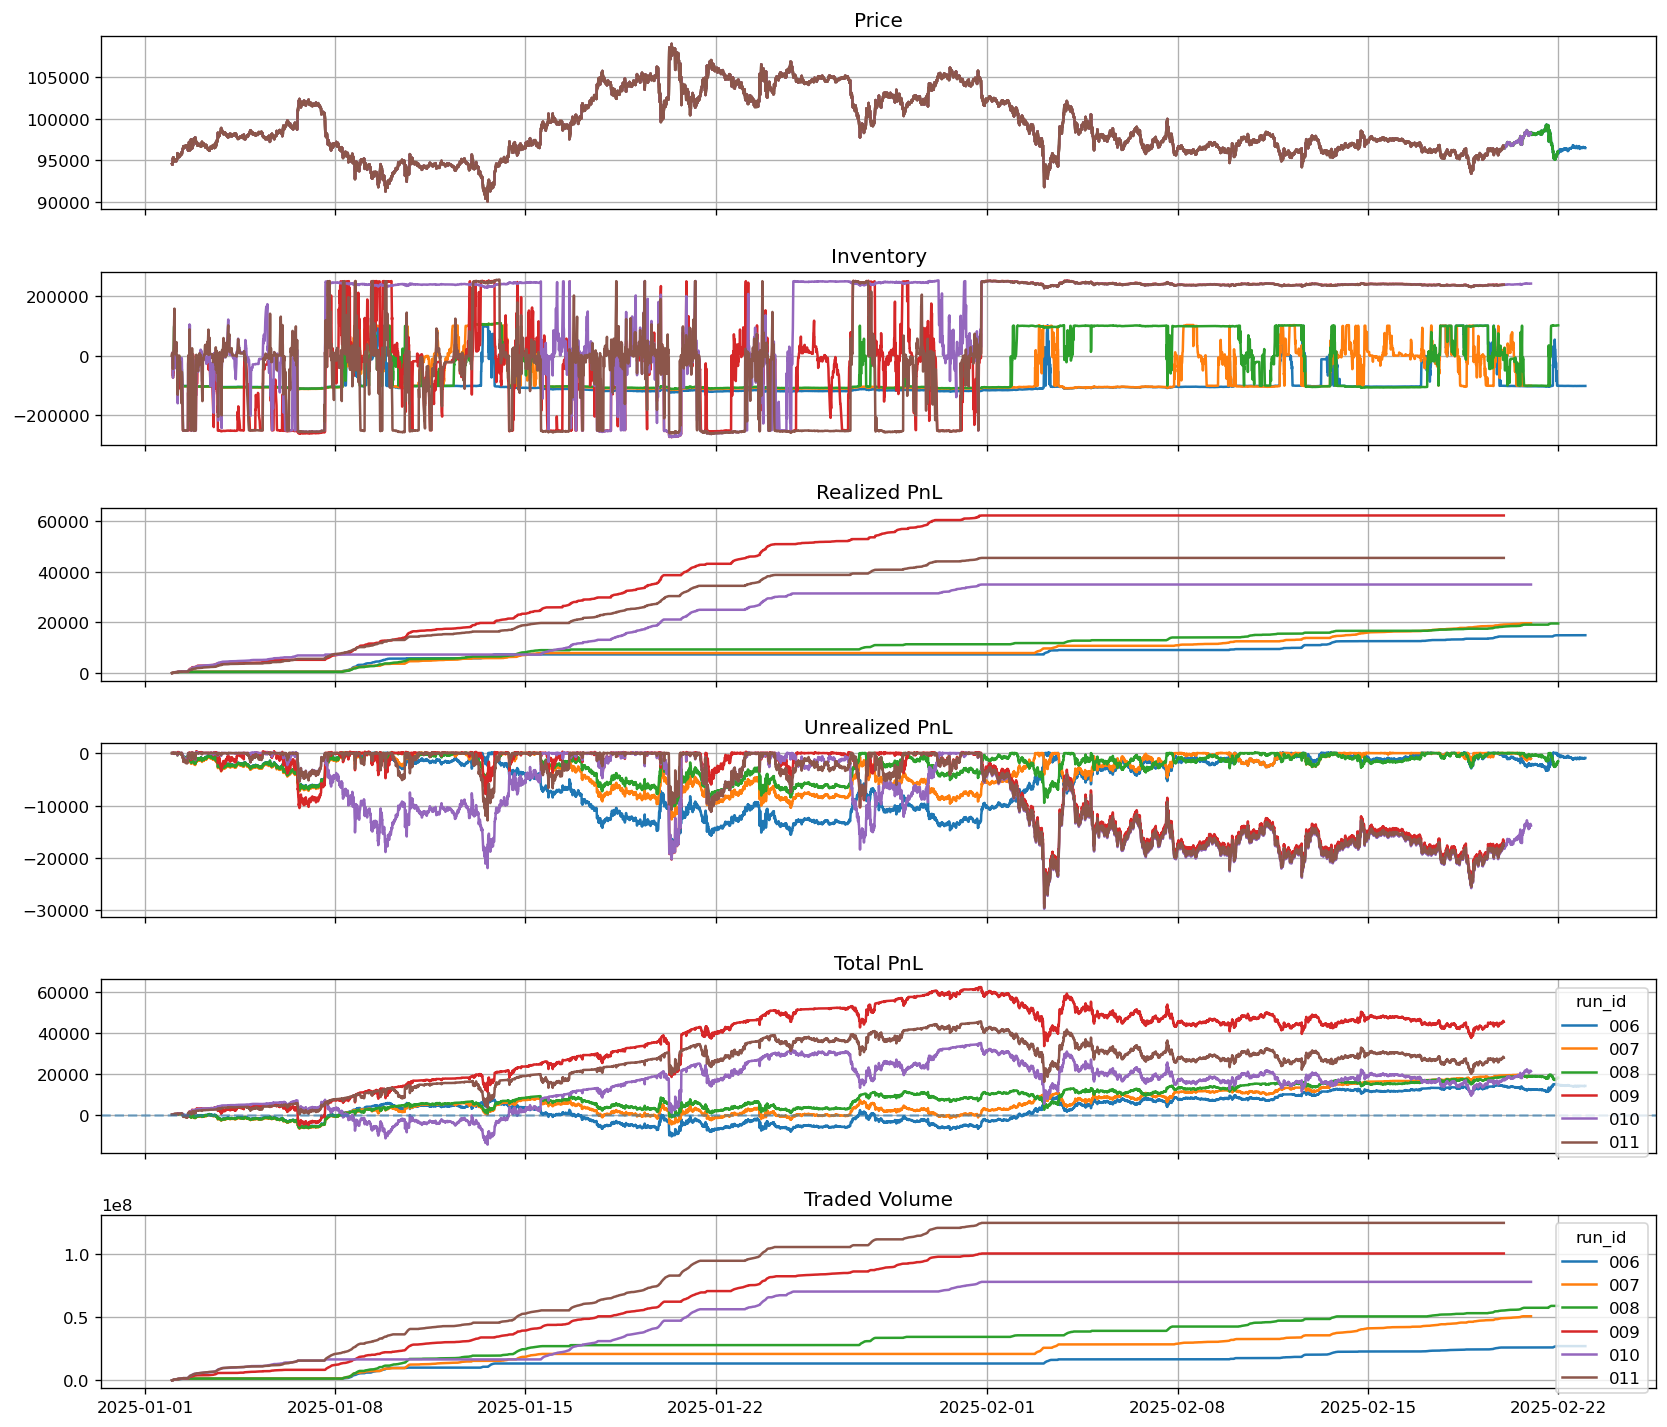

,run_id,file_count,folder,pnls,sharpes,calmars,max_drawdown,annual_return,calmar,sharpe,daily_turnover,spnl
0,006,51,/data/users/kang/backtest/glftmm_var/result/BTCUSDT/sim__asi1__asv0__fr1000__isk0x1__lat2__lbi300__vlb300__mfm3em05__mhtm1__mp500000__mon100__moq0__md1__ink__vnsigma__ocu0x1x0_...,14019.942498,0.130969,7.995358,13045.592754,104304.187823,7.995358,0.130969,5.038096e+05,0.000518
1,007,50,/data/users/kang/backtest/glftmm_var/result/BTCUSDT/sim__asi1__asv0__fr1000__isk0x1__lat2__lbi300__vlb300__mfm3em05__mhtm1__mp500000__mon100__moq0__md1__ink__vnsigma__ocu0x1x0_...,18601.543075,0.178928,16.490608,8791.973905,144984.998175,16.490608,0.178928,1.001907e+06,0.000368
2,008,51,/data/users/kang/backtest/glftmm_var/result/BTCUSDT/sim__asi1__asv0__fr1000__isk0x1__lat2__lbi300__vlb300__mfm3em05__mhtm1__mp500000__mon100__moq0__md1__ink__vnsigma__ocu0x1x0_...,18028.944651,0.174379,21.008340,6522.419668,137025.207705,21.008340,0.174379,1.145918e+06,0.000307
3,009,49,/data/users/kang/backtest/glftmm_var/result/BTCUSDT/sim__asi1__asv0__fr1000__isk0x1__lat2__lbi300__vlb300__mfm3em05__mhtm1__mp500000__mon100__moq0__md1__ink__vnsigma__ocu0x1x0_...,45288.138958,0.222531,18.657857,17237.012149,321605.708006,18.657857,0.222531,2.000260e+06,0.000453
4,010,50,/data/users/kang/backtest/glftmm_var/result/BTCUSDT/sim__asi1__asv0__fr1000__isk0x1__lat2__lbi300__vlb300__mfm3em05__mhtm1__mp500000__mon100__moq0__md1__ink__vnsigma__ocu0x1x0_...,21152.457056,0.092113,7.400105,18469.222095,136674.183696,7.400105,0.092113,1.469040e+06,0.000272
5,011,49,/data/users/kang/backtest/glftmm_var/result/BTCUSDT/sim__asi1__asv0__fr1000__isk0x1__lat2__lbi300__vlb300__mfm3em05__mhtm1__mp500000__mon100__moq0__md1__ink__vnsigma__ocu0x1x0_...,27806.859452,0.141789,10.644649,18422.593264,196102.037132,10.644649,0.141789,2.466995e+06,0.000224


batch 3: run_id 012..017


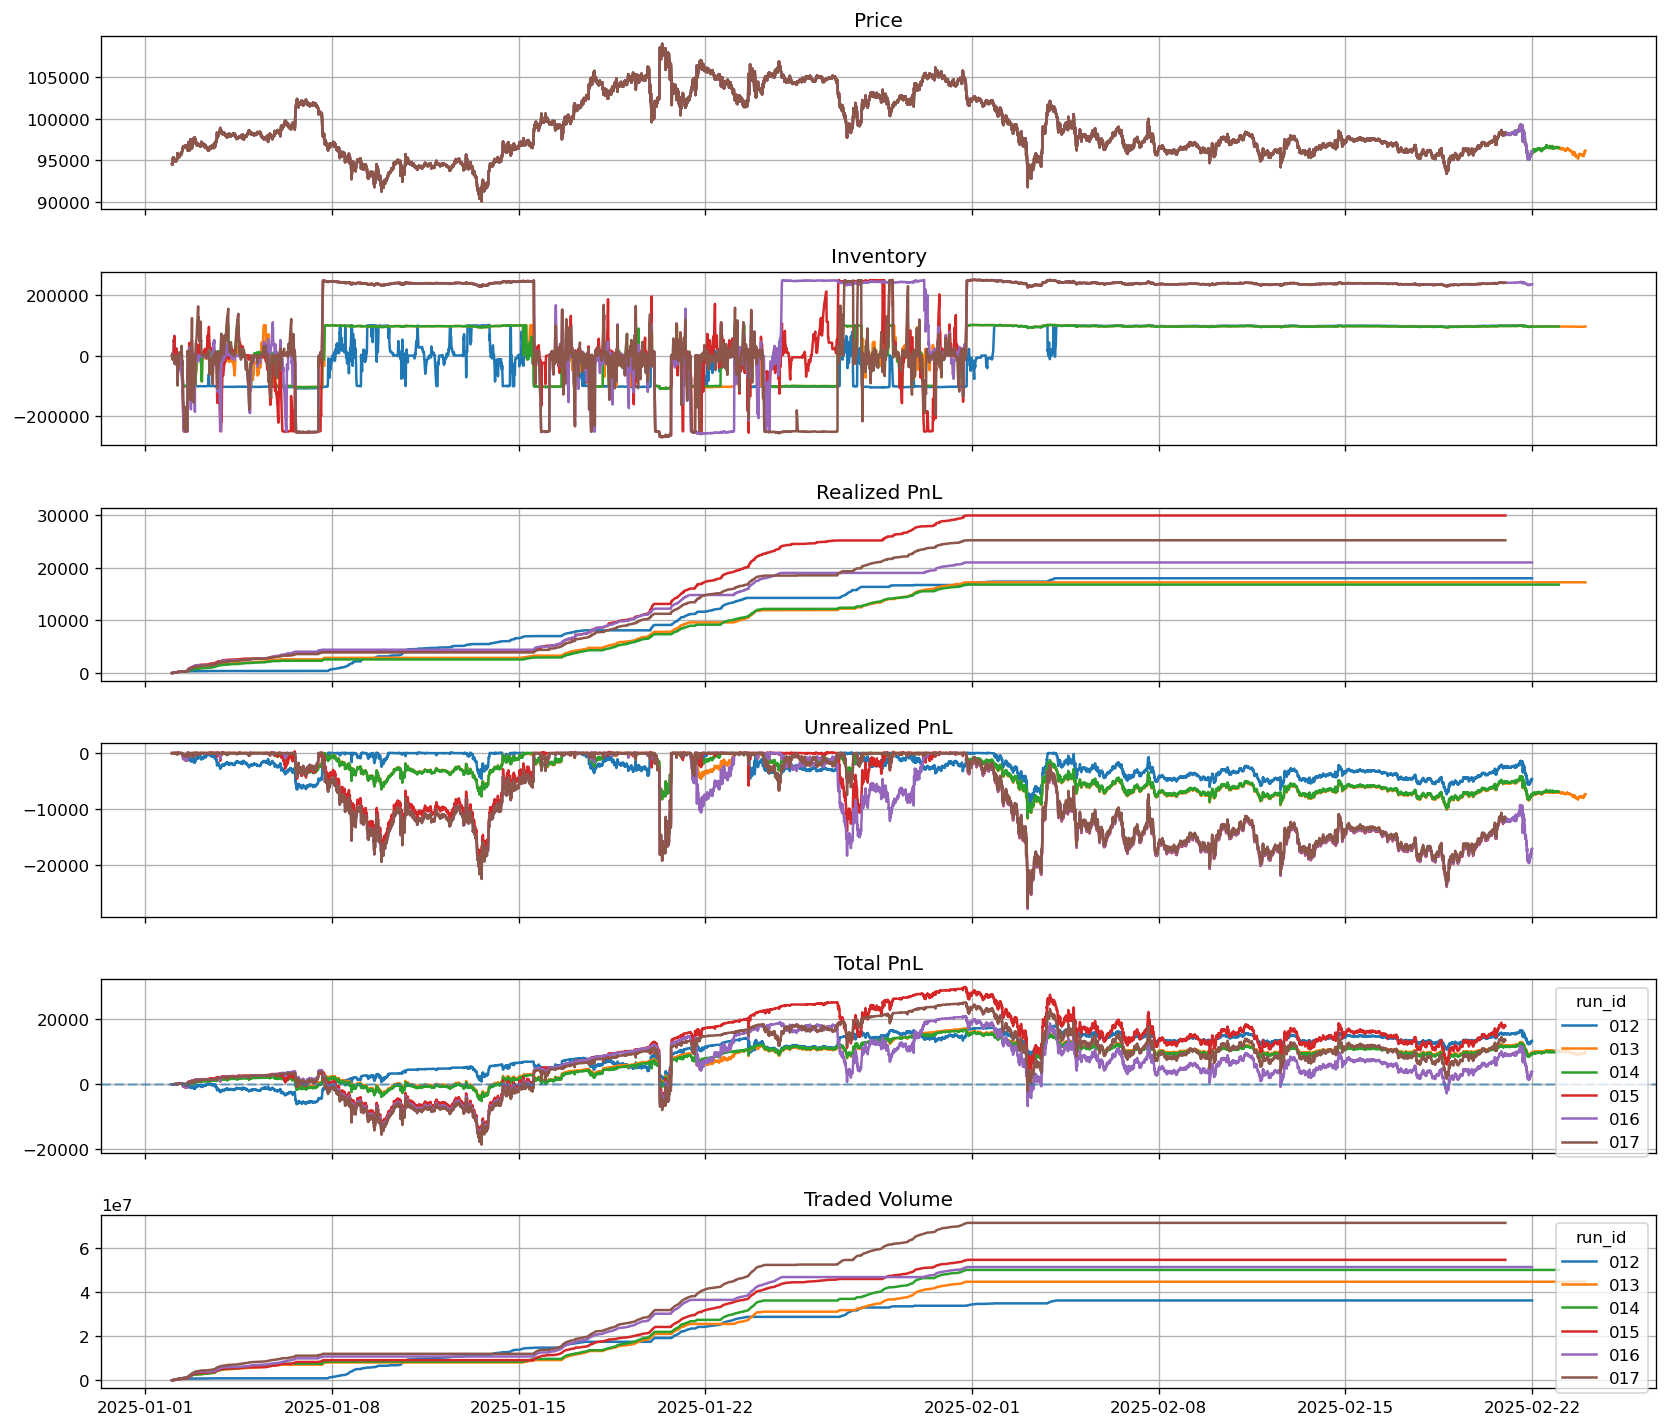

,run_id,file_count,folder,pnls,sharpes,calmars,max_drawdown,annual_return,calmar,sharpe,daily_turnover,spnl
0,012,50,/data/users/kang/backtest/glftmm_var/result/BTCUSDT/sim__asi1p5__asv0__fr1000__isk0x1__lat2__lbi300__vlb300__mfm3em05__mhtm1__mp500000__mon100__moq0__md0__ink__vnsigma__ocu0x1x...,13433.789033,0.145080,18.989485,5366.073555,101898.975710,18.989485,0.145080,7.057897e+05,0.000372
1,013,53,/data/users/kang/backtest/glftmm_var/result/BTCUSDT/sim__asi1p5__asv0__fr1000__isk0x1__lat2__lbi300__vlb300__mfm3em05__mhtm1__mp500000__mon100__moq0__md0__ink__vnsigma__ocu0x1x...,9970.970497,0.099209,8.862609,7141.486999,63292.204433,8.862609,0.099209,8.049120e+05,0.000224
2,014,52,/data/users/kang/backtest/glftmm_var/result/BTCUSDT/sim__asi1p5__asv0__fr1000__isk0x1__lat2__lbi300__vlb300__mfm3em05__mhtm1__mp500000__mon100__moq0__md0__ink__vnsigma__ocu0x1x...,9648.312754,0.102762,8.717099,7094.272562,61841.474025,8.717099,0.102762,9.074112e+05,0.000193
3,015,50,/data/users/kang/backtest/glftmm_var/result/BTCUSDT/sim__asi1p5__asv0__fr1000__isk0x1__lat2__lbi300__vlb300__mfm3em05__mhtm1__mp500000__mon100__moq0__md0__ink__vnsigma__ocu0x1x...,18026.938442,0.098025,7.087727,17331.782208,122842.945173,7.087727,0.098025,1.044438e+06,0.000331
4,016,51,/data/users/kang/backtest/glftmm_var/result/BTCUSDT/sim__asi1p5__asv0__fr1000__isk0x1__lat2__lbi300__vlb300__mfm3em05__mhtm1__mp500000__mon100__moq0__md0__ink__vnsigma__ocu0x1x...,4903.405986,0.017318,1.391864,17524.121288,24391.187602,1.391864,0.017318,9.287984e+05,0.000096
5,017,50,/data/users/kang/backtest/glftmm_var/result/BTCUSDT/sim__asi1p5__asv0__fr1000__isk0x1__lat2__lbi300__vlb300__mfm3em05__mhtm1__mp500000__mon100__moq0__md0__ink__vnsigma__ocu0x1x...,13643.311441,0.075566,5.311439,17368.010117,92249.122841,5.311439,0.075566,1.366543e+06,0.000192


batch 4: run_id 018..023


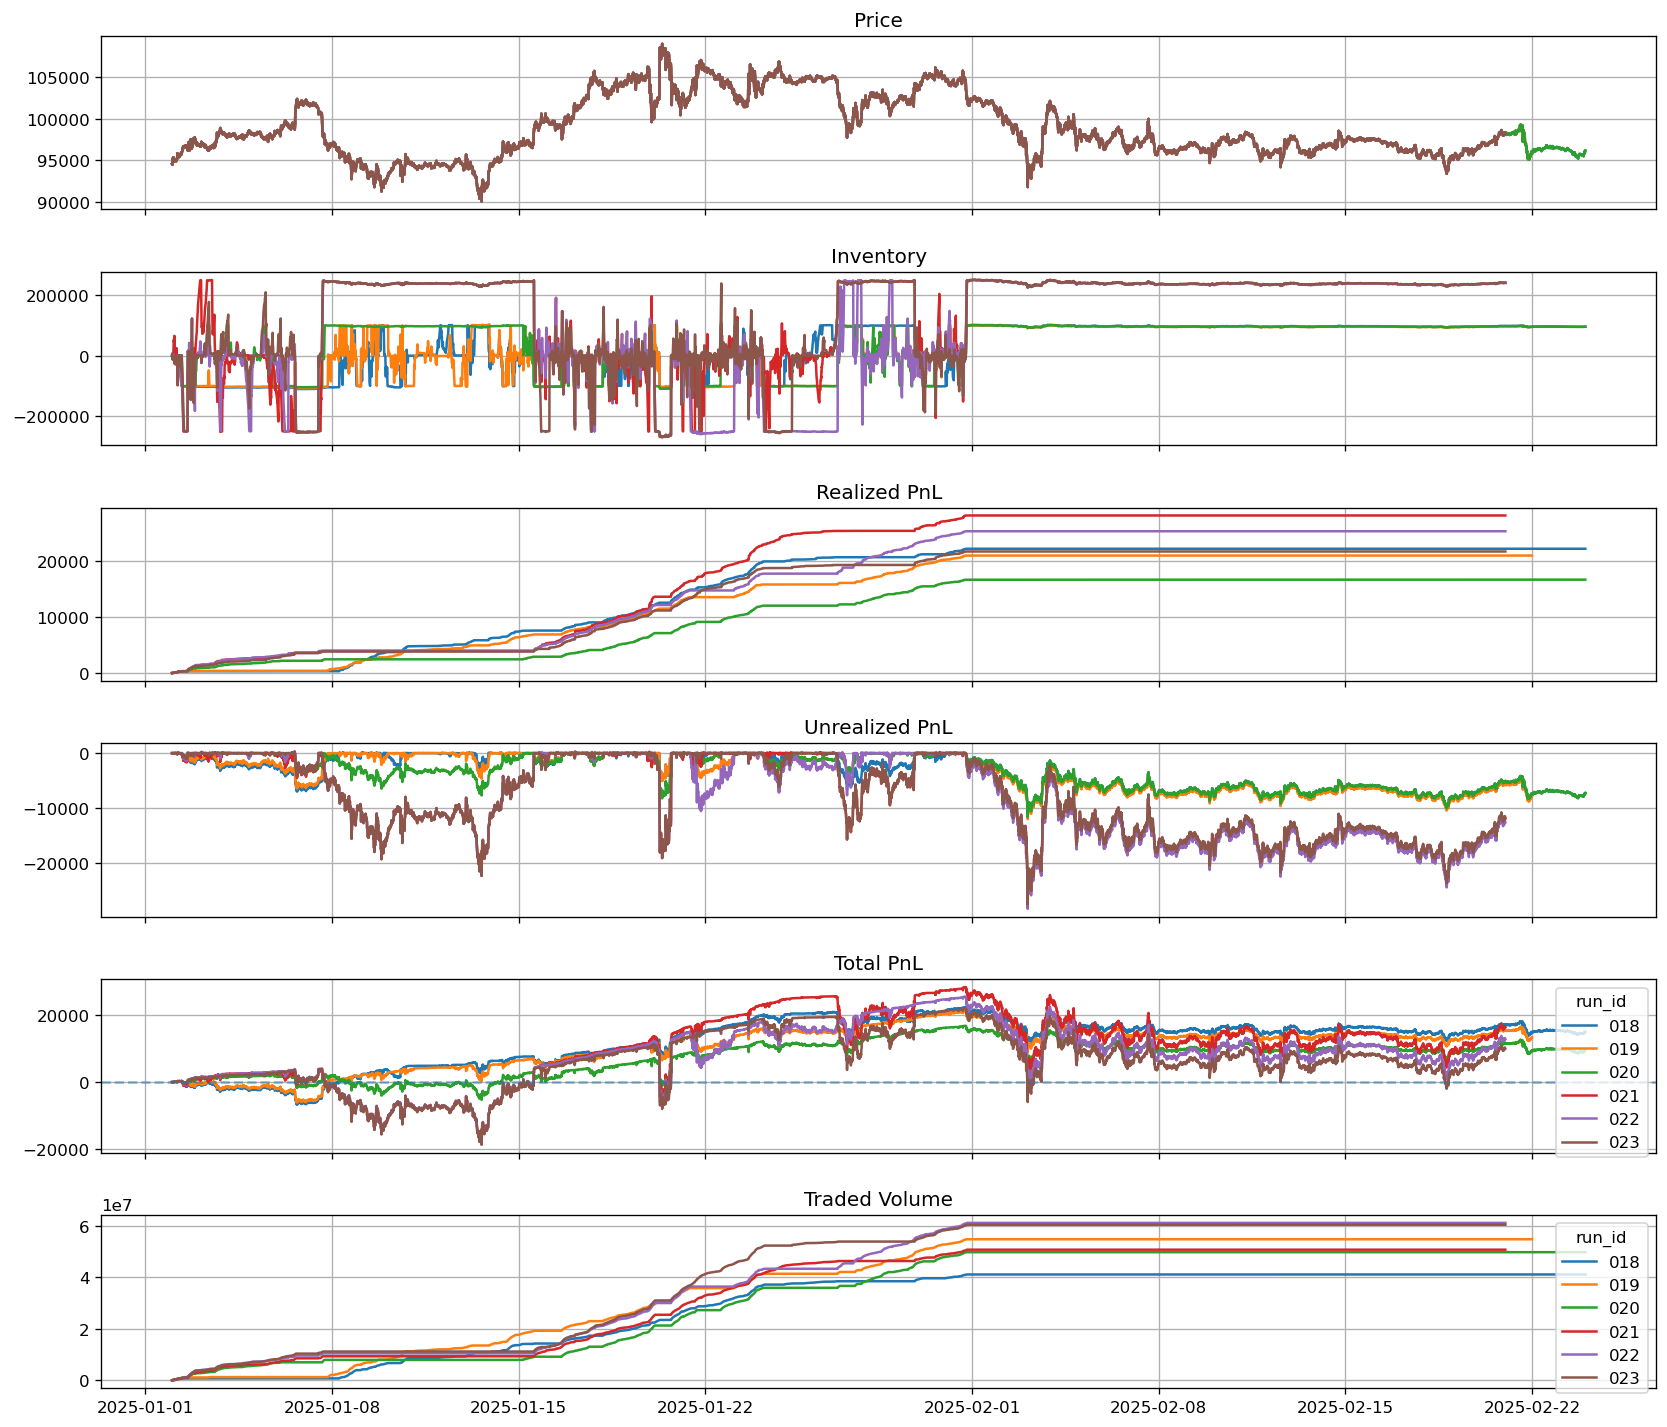

,run_id,file_count,folder,pnls,sharpes,calmars,max_drawdown,annual_return,calmar,sharpe,daily_turnover,spnl
0,018,53,/data/users/kang/backtest/glftmm_var/result/BTCUSDT/sim__asi1p5__asv0__fr1000__isk0x1__lat2__lbi300__vlb300__mfm3em05__mhtm1__mp500000__mon100__moq0__md1__ink__vnsigma__ocu0x1x...,15001.202147,0.161740,16.481299,6750.709331,111260.457815,16.481299,0.161740,7.756288e+05,0.000365
1,019,50,/data/users/kang/backtest/glftmm_var/result/BTCUSDT/sim__asi1p5__asv0__fr1000__isk0x1__lat2__lbi300__vlb300__mfm3em05__mhtm1__mp500000__mon100__moq0__md1__ink__vnsigma__ocu0x1x...,13243.465713,0.146142,13.379492,7513.057827,100520.899170,13.379492,0.146142,1.072315e+06,0.000242
2,020,52,/data/users/kang/backtest/glftmm_var/result/BTCUSDT/sim__asi1p5__asv0__fr1000__isk0x1__lat2__lbi300__vlb300__mfm3em05__mhtm1__mp500000__mon100__moq0__md1__ink__vnsigma__ocu0x1x...,9474.790334,0.101445,8.389444,7190.533325,60324.573627,8.389444,0.101445,9.029065e+05,0.000190
3,021,49,/data/users/kang/backtest/glftmm_var/result/BTCUSDT/sim__asi1p5__asv0__fr1000__isk0x1__lat2__lbi300__vlb300__mfm3em05__mhtm1__mp500000__mon100__moq0__md1__ink__vnsigma__ocu0x1x...,16251.311691,0.084307,6.480552,17363.541140,112525.324391,6.480552,0.084307,9.694634e+05,0.000320
4,022,50,/data/users/kang/backtest/glftmm_var/result/BTCUSDT/sim__asi1p5__asv0__fr1000__isk0x1__lat2__lbi300__vlb300__mfm3em05__mhtm1__mp500000__mon100__moq0__md1__ink__vnsigma__ocu0x1x...,12739.444531,0.062153,4.630408,18161.144342,84093.506492,4.630408,0.062153,1.168977e+06,0.000208
5,023,50,/data/users/kang/backtest/glftmm_var/result/BTCUSDT/sim__asi1p5__asv0__fr1000__isk0x1__lat2__lbi300__vlb300__mfm3em05__mhtm1__mp500000__mon100__moq0__md1__ink__vnsigma__ocu0x1x...,9949.857991,0.049629,3.670901,17597.447664,64598.493947,3.670901,0.049629,1.154244e+06,0.000165


,run_id,file_count,folder,pnls,sharpes,calmars,max_drawdown,annual_return,calmar,sharpe,daily_turnover,spnl
0,009,49,/data/users/kang/backtest/glftmm_var/result/BTCUSDT/sim__asi1__asv0__fr1000__isk0x1__lat2__lbi300__vlb300__mfm3em05__mhtm1__mp500000__mon100__moq0__md1__ink__vnsigma__ocu0x1x0_...,45288.138958,0.222531,18.657857,17237.012149,321605.708006,18.657857,0.222531,2.000260e+06,0.000453
1,003,51,/data/users/kang/backtest/glftmm_var/result/BTCUSDT/sim__asi1__asv0__fr1000__isk0x1__lat2__lbi300__vlb300__mfm3em05__mhtm1__mp500000__mon100__moq0__md0__ink__vnsigma__ocu0x1x0_...,30948.894845,0.116265,13.046239,15641.882637,204067.732333,13.046239,0.116265,1.015479e+06,0.000557
2,004,49,/data/users/kang/backtest/glftmm_var/result/BTCUSDT/sim__asi1__asv0__fr1000__isk0x1__lat2__lbi300__vlb300__mfm3em05__mhtm1__mp500000__mon100__moq0__md0__ink__vnsigma__ocu0x1x0_...,30909.107507,0.162238,11.612838,18405.295401,213737.721546,11.612838,0.162238,1.932128e+06,0.000310
3,011,49,/data/users/kang/backtest/glftmm_var/result/BTCUSDT/sim__asi1__asv0__fr1000__isk0x1__lat2__lbi300__vlb300__mfm3em05__mhtm1__mp500000__mon100__moq0__md1__ink__vnsigma__ocu0x1x0_...,27806.859452,0.141789,10.644649,18422.593264,196102.037132,10.644649,0.141789,2.466995e+06,0.000224
4,005,50,/data/users/kang/backtest/glftmm_var/result/BTCUSDT/sim__asi1__asv0__fr1000__isk0x1__lat2__lbi300__vlb300__mfm3em05__mhtm1__mp500000__mon100__moq0__md0__ink__vnsigma__ocu0x1x0_...,23598.885380,0.116149,8.841367,18149.513445,160466.503132,8.841367,0.116149,1.912918e+06,0.000237
5,010,50,/data/users/kang/backtest/glftmm_var/result/BTCUSDT/sim__asi1__asv0__fr1000__isk0x1__lat2__lbi300__vlb300__mfm3em05__mhtm1__mp500000__mon100__moq0__md1__ink__vnsigma__ocu0x1x0_...,21152.457056,0.092113,7.400105,18469.222095,136674.183696,7.400105,0.092113,1.469040e+06,0.000272
6,000,51,/data/users/kang/backtest/glftmm_var/result/BTCUSDT/sim__asi1__asv0__fr1000__isk0x1__lat2__lbi300__vlb300__mfm3em05__mhtm1__mp500000__mon100__moq0__md0__ink__vnsigma__ocu0x1x0_...,18668.346321,0.179090,10.694173,13126.996454,140382.370939,10.694173,0.179090,7.079169e+05,0.000513
7,007,50,/data/users/kang/backtest/glftmm_var/result/BTCUSDT/sim__asi1__asv0__fr1000__isk0x1__lat2__lbi300__vlb300__mfm3em05__mhtm1__mp500000__mon100__moq0__md1__ink__vnsigma__ocu0x1x0_...,18601.543075,0.178928,16.490608,8791.973905,144984.998175,16.490608,0.178928,1.001907e+06,0.000368
8,008,51,/data/users/kang/backtest/glftmm_var/result/BTCUSDT/sim__asi1__asv0__fr1000__isk0x1__lat2__lbi300__vlb300__mfm3em05__mhtm1__mp500000__mon100__moq0__md1__ink__vnsigma__ocu0x1x0_...,18028.944651,0.174379,21.008340,6522.419668,137025.207705,21.008340,0.174379,1.145918e+06,0.000307
9,015,50,/data/users/kang/backtest/glftmm_var/result/BTCUSDT/sim__asi1p5__asv0__fr1000__isk0x1__lat2__lbi300__vlb300__mfm3em05__mhtm1__mp500000__mon100__moq0__md0__ink__vnsigma__ocu0x1x...,18026.938442,0.098025,7.087727,17331.782208,122842.945173,7.087727,0.098025,1.044438e+06,0.000331


In [5]:
plot_df = choose_folders(limit=MAX_FOLDERS)
all_metrics = []

for start in range(0, len(plot_df), BATCH_SIZE):
    batch = plot_df.iloc[start : start + BATCH_SIZE]
    first_id = int(batch["run_id"].iloc[0])
    last_id = int(batch["run_id"].iloc[-1])
    print(f"batch {start // BATCH_SIZE + 1}: run_id {first_id:03d}..{last_id:03d}")
    all_metrics.append(plot_folder_batch(batch))

summary_df = pd.concat(all_metrics, ignore_index=True) if all_metrics else pd.DataFrame()
display(summary_df.sort_values("pnls", ascending=False).reset_index(drop=True))

Inspect one folder with the full report panels.

run_id=000
/data/users/kang/backtest/glftmm_var/result/BTCUSDT/sim__asi1__asv0__fr1000__isk0x1__lat2__lbi300__vlb300__mfm3em05__mhtm1__mp500000__mon100__moq0__md0__ink__vnsigma__ocu0x1x0__oa1000__pcp100000__pp1__pg5x105x10xexponentialx0p3__qp3__sl0p1__tf0p00025/strat__all


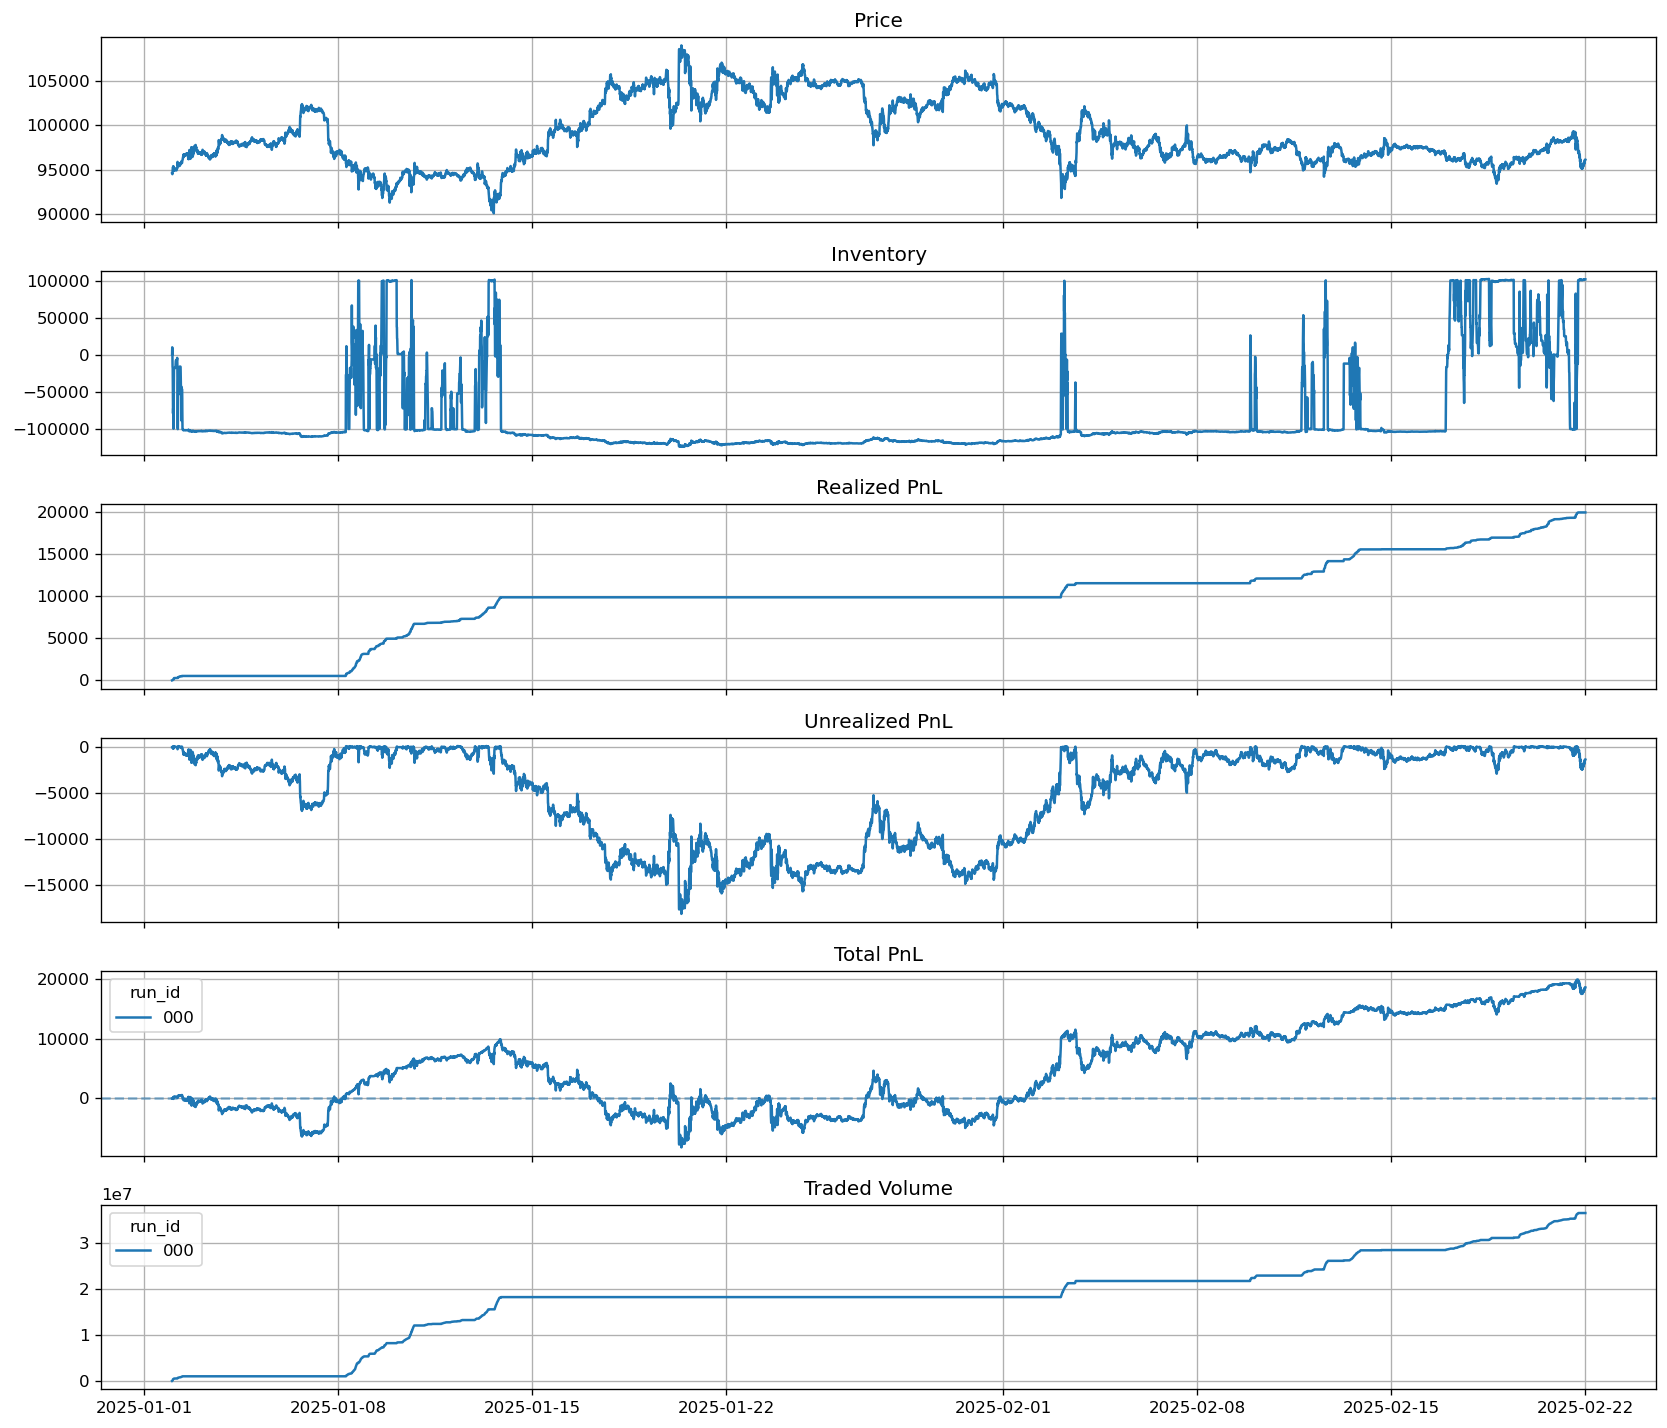

{'pnls': array([19066.27032117]),
 'sharpes': array([0.1810312]),
 'calmars': array([10.70143223]),
 'max_drawdown': array([13126.99645366]),
 'annual_return': array([140477.66288093]),
 'calmar': array([10.70143223]),
 'sharpe': array([0.1810312]),
 'daily_turnover': array([694036.14389021]),
 'spnl': array([0.00052378])}

In [6]:
FOLDER_ID = int(folder_df["run_id"].iloc[0])
one = folder_df.loc[folder_df["run_id"] == FOLDER_ID].iloc[0]

print(f"run_id={FOLDER_ID:03d}")
print(one["folder"])

report_tools.report(
    one["folder"],
    every=EVERY,
    pnl_only=False,
    srt=SRT,
    end=END,
    exclude_date=EXCLUDE_DATE,
    labels=[f"{FOLDER_ID:03d}"],
    normalize=NORMALIZE,
)

Compare selected folders on one PnL chart.

,run_id,run_name,file_count,folder
0,0,sim__asi1__asv0__fr1000__isk0x1__lat2__lbi300__vlb300__mfm3em05__mhtm1__mp500000__mon100__moq0__md0__ink__vnsigma__ocu0x1x0__oa1000__pcp100000__pp1__pg5x105x10xexponentialx0p3_...,51,/data/users/kang/backtest/glftmm_var/result/BTCUSDT/sim__asi1__asv0__fr1000__isk0x1__lat2__lbi300__vlb300__mfm3em05__mhtm1__mp500000__mon100__moq0__md0__ink__vnsigma__ocu0x1x0_...
1,1,sim__asi1__asv0__fr1000__isk0x1__lat2__lbi300__vlb300__mfm3em05__mhtm1__mp500000__mon100__moq0__md0__ink__vnsigma__ocu0x1x0__oa1000__pcp100000__pp1__pg5x55x10xpowerx2__qp3__sl0...,52,/data/users/kang/backtest/glftmm_var/result/BTCUSDT/sim__asi1__asv0__fr1000__isk0x1__lat2__lbi300__vlb300__mfm3em05__mhtm1__mp500000__mon100__moq0__md0__ink__vnsigma__ocu0x1x0_...
2,2,sim__asi1__asv0__fr1000__isk0x1__lat2__lbi300__vlb300__mfm3em05__mhtm1__mp500000__mon100__moq0__md0__ink__vnsigma__ocu0x1x0__oa1000__pcp100000__pp1__pg5x55x10xpowerx3__qp3__sl0...,53,/data/users/kang/backtest/glftmm_var/result/BTCUSDT/sim__asi1__asv0__fr1000__isk0x1__lat2__lbi300__vlb300__mfm3em05__mhtm1__mp500000__mon100__moq0__md0__ink__vnsigma__ocu0x1x0_...


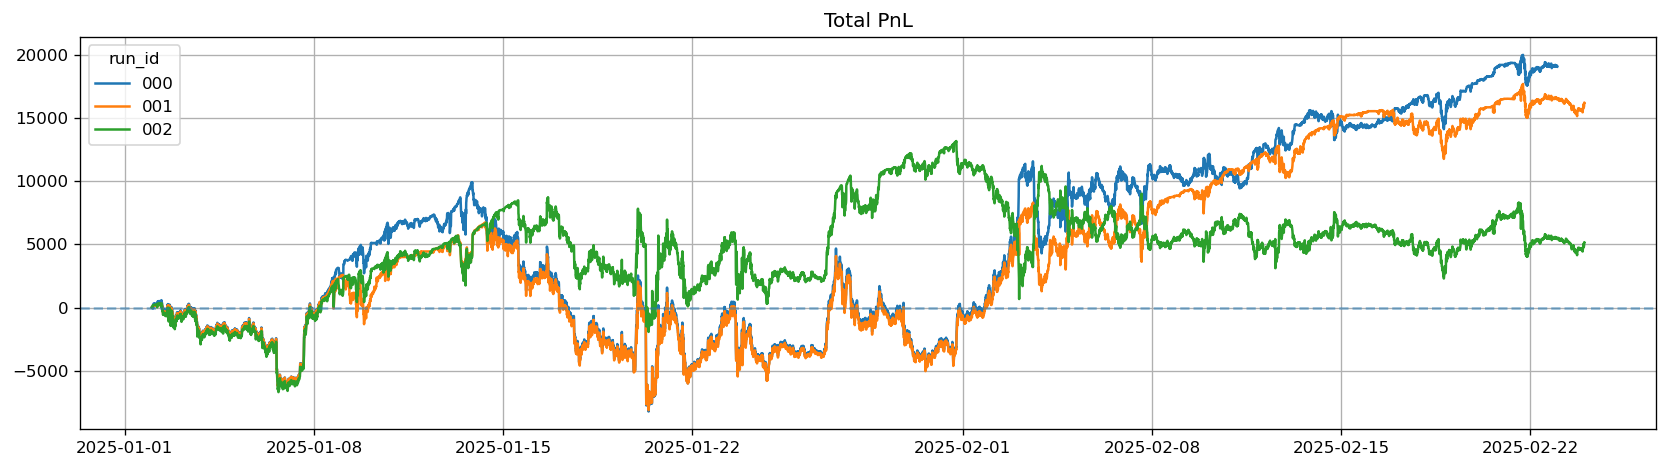

,run_id,file_count,folder,pnls,sharpes,calmars,max_drawdown,annual_return,calmar,sharpe,daily_turnover,spnl
0,000,51,/data/users/kang/backtest/glftmm_var/result/BTCUSDT/sim__asi1__asv0__fr1000__isk0x1__lat2__lbi300__vlb300__mfm3em05__mhtm1__mp500000__mon100__moq0__md0__ink__vnsigma__ocu0x1x0_...,19066.270321,0.181031,10.701432,13126.996454,140477.662881,10.701432,0.181031,694036.143890,0.000524
1,001,52,/data/users/kang/backtest/glftmm_var/result/BTCUSDT/sim__asi1__asv0__fr1000__isk0x1__lat2__lbi300__vlb300__mfm3em05__mhtm1__mp500000__mon100__moq0__md0__ink__vnsigma__ocu0x1x0_...,16209.799377,0.152100,10.648897,11106.089987,118267.606490,10.648897,0.152100,864372.151321,0.000352
2,002,53,/data/users/kang/backtest/glftmm_var/result/BTCUSDT/sim__asi1__asv0__fr1000__isk0x1__lat2__lbi300__vlb300__mfm3em05__mhtm1__mp500000__mon100__moq0__md0__ink__vnsigma__ocu0x1x0_...,5164.198978,0.056091,5.565252,7569.708078,42127.332614,5.565252,0.056091,759092.898638,0.000127


,run_id,file_count,folder,pnls,sharpes,calmars,max_drawdown,annual_return,calmar,sharpe,daily_turnover,spnl
0,000,51,/data/users/kang/backtest/glftmm_var/result/BTCUSDT/sim__asi1__asv0__fr1000__isk0x1__lat2__lbi300__vlb300__mfm3em05__mhtm1__mp500000__mon100__moq0__md0__ink__vnsigma__ocu0x1x0_...,19066.270321,0.181031,10.701432,13126.996454,140477.662881,10.701432,0.181031,694036.143890,0.000524
1,001,52,/data/users/kang/backtest/glftmm_var/result/BTCUSDT/sim__asi1__asv0__fr1000__isk0x1__lat2__lbi300__vlb300__mfm3em05__mhtm1__mp500000__mon100__moq0__md0__ink__vnsigma__ocu0x1x0_...,16209.799377,0.152100,10.648897,11106.089987,118267.606490,10.648897,0.152100,864372.151321,0.000352
2,002,53,/data/users/kang/backtest/glftmm_var/result/BTCUSDT/sim__asi1__asv0__fr1000__isk0x1__lat2__lbi300__vlb300__mfm3em05__mhtm1__mp500000__mon100__moq0__md0__ink__vnsigma__ocu0x1x0_...,5164.198978,0.056091,5.565252,7569.708078,42127.332614,5.565252,0.056091,759092.898638,0.000127


In [7]:
SELECTED_IDS = [0, 1, 2]
selected = choose_folders(indices=SELECTED_IDS)
display(selected)

plot_folder_batch(selected, pnl_only=True)

In [10]:
summary_df.sort_values("pnls", ascending=False).iloc[0].folder

'/data/users/kang/backtest/glftmm_var/result/BTCUSDT/sim__asi1__asv0__fr1000__isk0x1__lat2__lbi300__vlb300__mfm3em05__mhtm1__mp500000__mon100__moq0__md1__ink__vnsigma__ocu0x1x0__oa1000__pcp250000__pp1__pg5x105x10xexponentialx0p3__qp3__sl0p1__tf0p00025/strat__all'